<a href="https://colab.research.google.com/github/adithyarhm/belajar-kolaborasi/blob/main/%5BDICODING%5D_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Deep Learning Sentiment Analysis for Dicoding Submission

Notebook ini disusun untuk submission analisis sentimen berbasis deep learning menggunakan dataset hasil scraping mandiri dari Google Play Store. Label sentimen dibuat menjadi **3 kelas** dari rating aplikasi:
- **negative**: skor 1-2
- **neutral**: skor 3
- **positive**: skor 4-5

Notebook ini memuat **3 skema pelatihan deep learning**:
1. Embedding + GlobalAveragePooling1D
2. Embedding + Conv1D + GlobalMaxPooling1D
3. Embedding + Bidirectional LSTM

Di bagian akhir tersedia evaluasi, perbandingan model, penyimpanan artefak, dan inference pada contoh kalimat baru.


## 1. Import Library

In [ ]:

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, GlobalAveragePooling1D, Conv1D, GlobalMaxPooling1D, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.19.0


## 2. Load Dataset

In [ ]:

DATA_PATH = 'ulasan_aplikasi_clean.csv'
df = pd.read_csv(DATA_PATH)
print('Shape dataset awal:', df.shape)
df.head()


Shape dataset awal: (11000, 11)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,fea3cf9a-c279-4ed8-83eb-6aec03631ebf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,4.14.3,2025-03-26 08:49:58,Yth. Bapak/Ibu pengguna aplikasi BPJS Ketenaga...,2025-03-27 03:01:10,4.14.3
1,a7d69f6c-cca6-45e1-9ecb-c491250afb5f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,1,0,4.15.17,2026-01-23 12:37:11,Yth. Bapak/Ibu pengguna aplikasi BPJS Ketenaga...,2026-01-26 05:47:22,4.15.17
2,abf49e6e-9535-4ffe-bb25-f1379a0974ad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Knpa saya ga bisa daftar ya?? Selalu disuruh i...,2,0,3.1.33,2020-02-11 09:23:36,"Yth. Ibu Aida Nur Aisyah Rahman,\nUntuk Proses...",2020-02-12 15:09:29,3.1.33
3,1b86b192-8f18-4cdf-b653-b86831d3c3fa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa semakin sering di update mlah jdi kelua...,3,0,3.1.30,2020-06-11 11:59:56,"Yth. Bapak/Ibu,\nUntuk masalah Forced close, M...",2020-06-12 16:03:29,3.1.30
4,fb47db76-fdad-49d7-ad8f-f064c6df52aa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gimana sih aplikasi,udah berhasil registrasi,,...",1,0,3.1.27,2019-01-03 17:55:23,"Yth. Bapak Ragil,\nUntuk permasalahan Forced c...",2018-09-26 08:47:23,3.1.27


In [ ]:

df.columns.tolist()


['reviewId',
 'userName',
 'userImage',
 'content',
 'score',
 'thumbsUpCount',
 'reviewCreatedVersion',
 'at',
 'replyContent',
 'repliedAt',
 'appVersion']

## 3. Siapkan Kolom Teks dan Label

In [ ]:

text_candidates = ['textakhir', 'textclean', 'textslangwords', 'textcasefoldingText', 'content']
text_col = None
for col in text_candidates:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError('Kolom teks tidak ditemukan.')

print('Kolom teks yang digunakan:', text_col)


Kolom teks yang digunakan: content


In [ ]:

df = df[[text_col, 'score']].copy()
df = df.dropna()
df[text_col] = df[text_col].astype(str).str.strip()
df = df[df[text_col] != '']

def map_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'


df['label'] = df['score'].apply(map_sentiment)
print('Shape setelah cleaning:', df.shape)
df.head()


Shape setelah cleaning: (11000, 3)


,content,score,label
0,baik,5,positive
1,mantap,1,negative
2,Knpa saya ga bisa daftar ya?? Selalu disuruh i...,2,negative
3,Kenapa semakin sering di update mlah jdi kelua...,3,neutral
4,"gimana sih aplikasi,udah berhasil registrasi,,...",1,negative


In [ ]:

label_counts = df['label'].value_counts()
label_counts


,count
label,
positive,6285
negative,4041
neutral,674


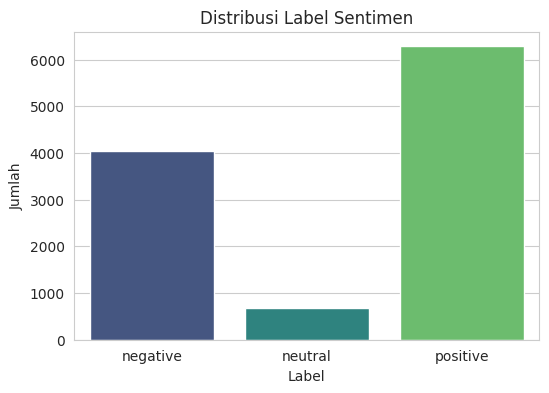

In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', order=['negative','neutral','positive'], palette='viridis')
plt.title('Distribusi Label Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()


## 4. Encoding Label dan Split Data

In [ ]:

label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['label'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
inv_label_mapping = {v:k for k,v in label_mapping.items()}
print('Mapping label:', label_mapping)


Mapping label: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [ ]:

X = df[text_col].values
y = df['label_id'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print('Jumlah data train:', len(X_train))
print('Jumlah data test :', len(X_test))


Jumlah data train: 8800
Jumlah data test : 2200


## 5. Tokenisasi dan Padding

In [ ]:

MAX_WORDS = 20000
MAX_LEN = 100
EMBED_DIM = 128


tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

num_classes = len(label_encoder.classes_)
actual_vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print('Jumlah kelas:', num_classes)
print('Vocab size   :', actual_vocab_size)
print('Shape train  :', X_train_pad.shape)
print('Shape test   :', X_test_pad.shape)


Jumlah kelas: 3
Vocab size   : 7507
Shape train  : (8800, 100)
Shape test   : (2200, 100)


## 6. Definisikan Fungsi Model dan Evaluasi

In [ ]:

def build_model_gap(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        GlobalAveragePooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model


def build_model_cnn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        Conv1D(128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model


def build_model_bilstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model


def compile_model(model):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]


def evaluate_model(model, X_test_pad, y_test, model_name):
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    return acc, report, cm, y_pred


## 7. Training Skema 1 - Embedding + GlobalAveragePooling1D

In [ ]:

model_gap = build_model_gap(actual_vocab_size, EMBED_DIM, MAX_LEN, num_classes)
model_gap = compile_model(model_gap)
model_gap.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_gap = model_gap.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks('gap'),
    verbose=1
)


Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5979 - loss: 0.8290 - val_accuracy: 0.7193 - val_loss: 0.7243 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7497 - loss: 0.6649 - val_accuracy: 0.7937 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7901 - loss: 0.5845 - val_accuracy: 0.8199 - val_loss: 0.5329 - learning_rate: 0.0010
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8010 - loss: 0.5581 - val_accuracy: 0.8261 - val_loss: 0.5093 - learning_rate: 0.0010
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8107 - loss: 0.5372 - val_accuracy: 0.8347 - val_loss: 0.4976 - learning_rate: 0.0010
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8206 - loss: 0.5166 - val_accuracy: 0.8432 - val_loss: 0.4876 - learning_rate: 0.0010
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8293 - loss: 0.

In [ ]:

acc_gap, report_gap, cm_gap, y_pred_gap = evaluate_model(model_gap, X_test_pad, y_test, 'GAP')
print('Test Accuracy GAP:', acc_gap)
pd.DataFrame(report_gap).transpose()


Test Accuracy GAP: 0.83


,precision,recall,f1-score,support
negative,0.749474,0.881188,0.810011,808.00
neutral,0.000000,0.000000,0.000000,135.00
positive,0.891200,0.886237,0.888712,1257.00
accuracy,0.830000,0.830000,0.830000,0.83
macro avg,0.546891,0.589142,0.566241,2200.00
weighted avg,0.784461,0.830000,0.805273,2200.00


## 8. Training Skema 2 - Embedding + Conv1D + GlobalMaxPooling1D

In [ ]:

model_cnn = build_model_cnn(actual_vocab_size, EMBED_DIM, MAX_LEN, num_classes)
model_cnn = compile_model(model_cnn)
model_cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks('cnn'),
    verbose=1
)


Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.7838 - loss: 0.5920 - val_accuracy: 0.8517 - val_loss: 0.4523 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.8635 - loss: 0.4162 - val_accuracy: 0.8500 - val_loss: 0.4550 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8879 - loss: 0.3449
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9020 - loss: 0.3069 - val_accuracy: 0.8528 - val_loss: 0.4973 - learning_rate: 0.0010
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9416 - loss: 0.2042 - val_accuracy: 0.8426 - val_loss: 0.5555 - learning_rate: 5.0000e-04
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9542 - loss: 0.1719
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9604 - l

In [ ]:

acc_cnn, report_cnn, cm_cnn, y_pred_cnn = evaluate_model(model_cnn, X_test_pad, y_test, 'CNN')
print('Test Accuracy CNN:', acc_cnn)
pd.DataFrame(report_cnn).transpose()


Test Accuracy CNN: 0.8309090909090909


,precision,recall,f1-score,support
negative,0.764770,0.865099,0.811847,808.000000
neutral,0.190476,0.029630,0.051282,135.000000
positive,0.889328,0.894988,0.892149,1257.000000
accuracy,0.830909,0.830909,0.830909,0.830909
macro avg,0.614858,0.596572,0.585093,2200.000000
weighted avg,0.800697,0.830909,0.811058,2200.000000


## 9. Training Skema 3 - Embedding + Bidirectional LSTM

In [ ]:

model_bilstm = build_model_bilstm(actual_vocab_size, EMBED_DIM, MAX_LEN, num_classes)
model_bilstm = compile_model(model_bilstm)
model_bilstm.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_bilstm = model_bilstm.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks('bilstm'),
    verbose=1
)


Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 58s 234ms/step - accuracy: 0.7842 - loss: 0.5913 - val_accuracy: 0.8386 - val_loss: 0.4673 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 51s 231ms/step - accuracy: 0.8537 - loss: 0.4428 - val_accuracy: 0.8562 - val_loss: 0.4473 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 49s 222ms/step - accuracy: 0.8787 - loss: 0.3721 - val_accuracy: 0.8449 - val_loss: 0.4721 - learning_rate: 0.0010
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8927 - loss: 0.3360
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
220/220 ━━━━━━━━━━━━━━━━━━━━ 84s 232ms/step - accuracy: 0.8996 - loss: 0.3194 - val_accuracy: 0.8386 - val_loss: 0.5144 - learning_rate: 0.0010
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 49s 222ms/step - accuracy: 0.9233 - loss: 0.2533 - val_accuracy: 0.8398 - val_loss: 0.5778 - learning_rate: 5.0000e-04


In [ ]:

acc_bilstm, report_bilstm, cm_bilstm, y_pred_bilstm = evaluate_model(model_bilstm, X_test_pad, y_test, 'BiLSTM')
print('Test Accuracy BiLSTM:', acc_bilstm)
pd.DataFrame(report_bilstm).transpose()


Test Accuracy BiLSTM: 0.835


,precision,recall,f1-score,support
negative,0.761803,0.878713,0.816092,808.000
neutral,0.000000,0.000000,0.000000,135.000
positive,0.888801,0.896579,0.892673,1257.000
accuracy,0.835000,0.835000,0.835000,0.835
macro avg,0.550201,0.591764,0.569588,2200.000
weighted avg,0.787618,0.835000,0.809769,2200.000


## 10. Bandingkan Semua Model

In [ ]:

results_df = pd.DataFrame([
    {'model': 'Embedding + GAP', 'test_accuracy': acc_gap},
    {'model': 'Embedding + CNN', 'test_accuracy': acc_cnn},
    {'model': 'Embedding + BiLSTM', 'test_accuracy': acc_bilstm},
]).sort_values(by='test_accuracy', ascending=False).reset_index(drop=True)

results_df


,model,test_accuracy
0,Embedding + BiLSTM,0.835000
1,Embedding + CNN,0.830909
2,Embedding + GAP,0.830000


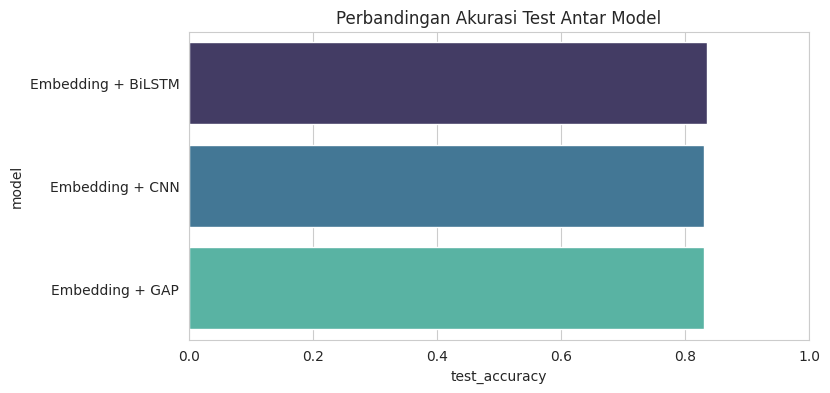

In [ ]:

plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x='test_accuracy', y='model', palette='mako')
plt.title('Perbandingan Akurasi Test Antar Model')
plt.xlim(0, 1)
plt.show()


## 11. Confusion Matrix Model Terbaik

In [ ]:

best_model_name = results_df.loc[0, 'model']

if best_model_name == 'Embedding + GAP':
    best_model = model_gap
    best_cm = cm_gap
elif best_model_name == 'Embedding + CNN':
    best_model = model_cnn
    best_cm = cm_cnn
else:
    best_model = model_bilstm
    best_cm = cm_bilstm

print('Model terbaik:', best_model_name)


Model terbaik: Embedding + BiLSTM


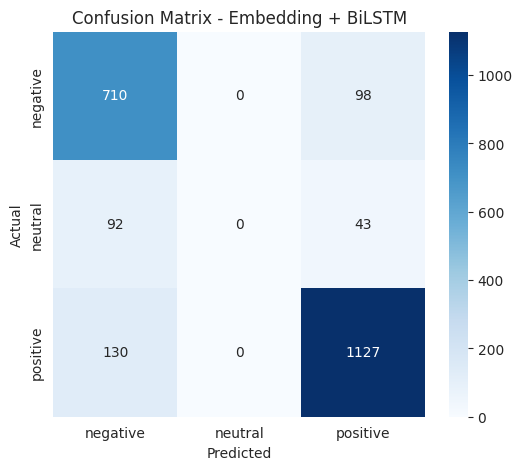

In [ ]:

plt.figure(figsize=(6,5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 12. Simpan Artefak Model

In [ ]:

os.makedirs('submission_artifacts', exist_ok=True)

best_model.save('submission_artifacts/best_model.keras')

with open('submission_artifacts/tokenizer_config.json', 'w', encoding='utf-8') as f:
    json.dump(tokenizer.to_json(), f, ensure_ascii=False)

with open('submission_artifacts/label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in inv_label_mapping.items()}, f, ensure_ascii=False, indent=2)

results_df.to_csv('submission_artifacts/model_comparison.csv', index=False)

print('Artefak berhasil disimpan.')


Artefak berhasil disimpan.


## 13. Inference / Prediksi Kalimat Baru

In [ ]:

def predict_sentiment(text, model, tokenizer, max_len, inv_label_mapping):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = model.predict(pad, verbose=0)
    label_id = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))
    label = inv_label_mapping[label_id]
    return label, confidence

sample_texts = [
    'aplikasinya sangat membantu dan fiturnya bagus',
    'biasa saja, tidak terlalu bagus tapi tidak jelek',
    'aplikasi ini buruk, sering error dan susah login'
]

for text in sample_texts:
    label, confidence = predict_sentiment(text, best_model, tokenizer, MAX_LEN, inv_label_mapping)
    print(f'Teks      : {text}')
    print(f'Prediksi  : {label}')
    print(f'Confidence: {confidence:.4f}')
    print('-'*60)


Teks      : aplikasinya sangat membantu dan fiturnya bagus
Prediksi  : positive
Confidence: 0.9691
------------------------------------------------------------
Teks      : biasa saja, tidak terlalu bagus tapi tidak jelek
Prediksi  : negative
Confidence: 0.8989
------------------------------------------------------------
Teks      : aplikasi ini buruk, sering error dan susah login
Prediksi  : negative
Confidence: 0.9769
------------------------------------------------------------


## 14. Kesimpulan Singkat

In [ ]:
print('Distribusi label:')
print(df['label'].value_counts())
print('\nHasil perbandingan model:')
print(results_df)

Distribusi label:
label
positive    6285
negative    4041
neutral      674
Name: count, dtype: int64

Hasil perbandingan model:
                model  test_accuracy
0  Embedding + BiLSTM       0.835000
1     Embedding + CNN       0.830909
2     Embedding + GAP       0.830000
